## Summarize improvement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH_COMPLETE = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv"
PATH_MINIMAL  = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv"

DATASET_COLORS = {
    "eth_micron": "#2bbfa4",
    "lka_micron": "#f4693d",
    "lka_vam":    "#7b8fd4",
    "moz_vam":    "#f06caa",
    "nga_micron": "#92c63e",
    "nga_mics":   "#f5c100",
    "yem_mvam":   "#c8a86b",
    "zwe_mics":   "#aaaaaa",
}

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
def load_var_exp(path, train_percent=1):
    cols_needed = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "seed", "adm1_code", "adm1_name", "target",
        "emd_gen", "emd_over",
        "absmeanerr_gen", "absmeanerr_over",
    ]
    raw = pd.read_csv(path, usecols=lambda c: c in cols_needed)

    # filter to the desired train_percent only
    raw = raw[raw["train_percent_int"] == train_percent].copy()

    # step 1: average over seeds → one row per (experiment, adm1, target)
    group_keys = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "adm1_code", "adm1_name", "target"
    ]
    adm1_seedmean = (
        raw.groupby(group_keys, as_index=False)
           .agg(
               emd_gen_mean  =("emd_gen",        "mean"),
               emd_over_mean =("emd_over",       "mean"),
               abs_gen_mean  =("absmeanerr_gen", "mean"),
               abs_over_mean =("absmeanerr_over","mean"),
           )
    )

    # step 2: average over adm1 → one row per (experiment, target)
    keys_var = ["experiment_id", "country", "dataset", "train_percent_int", "target"]
    var_exp = (
        adm1_seedmean.groupby(keys_var, as_index=False)
                     .agg(
                         emd_gen_mean  =("emd_gen_mean",  "mean"),
                         emd_over_mean =("emd_over_mean", "mean"),
                         abs_gen_mean  =("abs_gen_mean",  "mean"),
                         abs_over_mean =("abs_over_mean", "mean"),
                     )
    )

    var_exp["emd_improv"] = var_exp["emd_over_mean"] - var_exp["emd_gen_mean"]
    var_exp["ame_improv"] = var_exp["abs_over_mean"] - var_exp["abs_gen_mean"]
    return var_exp

var_exp_complete = load_var_exp(PATH_COMPLETE, train_percent=1)
var_exp_complete["model"] = "complete"

var_exp_minimal = load_var_exp(PATH_MINIMAL, train_percent=1)
var_exp_minimal["model"] = "minimal"

print("complete:", var_exp_complete.shape, "  minimal:", var_exp_minimal.shape)
print("\ncomplete experiments:", var_exp_complete["experiment_id"].unique())
print("minimal experiments: ", var_exp_minimal["experiment_id"].unique())

complete: (38, 12)   minimal: (38, 12)

complete experiments: ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'zwe_mics']
minimal experiments:  ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'zwe_mics']


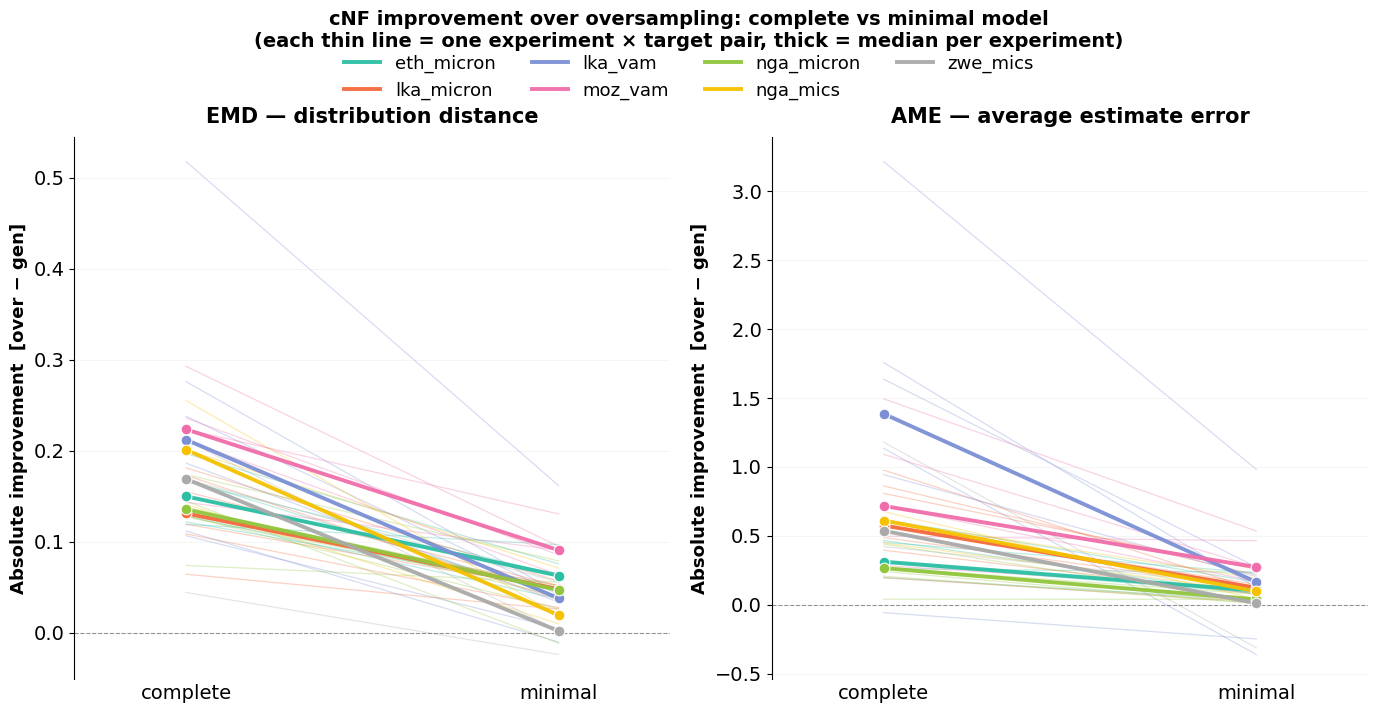

In [3]:
def slope_panel(ax, metric_col, ylabel, title):
    # merge complete and minimal on (experiment, target) so each row is one paired point
    merge_keys = ["experiment_id", "country", "dataset", "target"]
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    exp_ids = sorted(merged["experiment_id"].unique())

    for exp in exp_ids:
        sub = merged[merged["experiment_id"] == exp]
        color = DATASET_COLORS.get(exp, "#999999")

        # one thin line per (experiment, target) point
        for _, row in sub.iterrows():
            ax.plot(
                [0, 1],
                [row[f"{metric_col}_complete"], row[f"{metric_col}_minimal"]],
                color=color, linewidth=0.9, alpha=0.3, zorder=1
            )

        # thick median line per experiment
        med_c = sub[f"{metric_col}_complete"].median()
        med_m = sub[f"{metric_col}_minimal"].median()
        ax.plot(
            [0, 1], [med_c, med_m],
            color=color, linewidth=2.8, alpha=0.95, zorder=2, label=exp
        )
        ax.scatter(
            [0, 1], [med_c, med_m],
            color=color, s=60, zorder=3, edgecolors="white", linewidths=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["complete", "minimal"], fontsize=14)
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", length=0)

    return ax.get_legend_handles_labels()


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.10, wspace=0.35)

handles, labels = slope_panel(
    axes[0],
    metric_col="emd_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="EMD — distribution distance",
)
slope_panel(
    axes[1],
    metric_col="ame_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="AME — average estimate error",
)

fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 0.98),
    ncol=4, frameon=False, fontsize=13,
)
fig.suptitle(
    "cNF improvement over oversampling: complete vs minimal model\n"
    "(each thin line = one experiment × target pair, thick = median per experiment)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

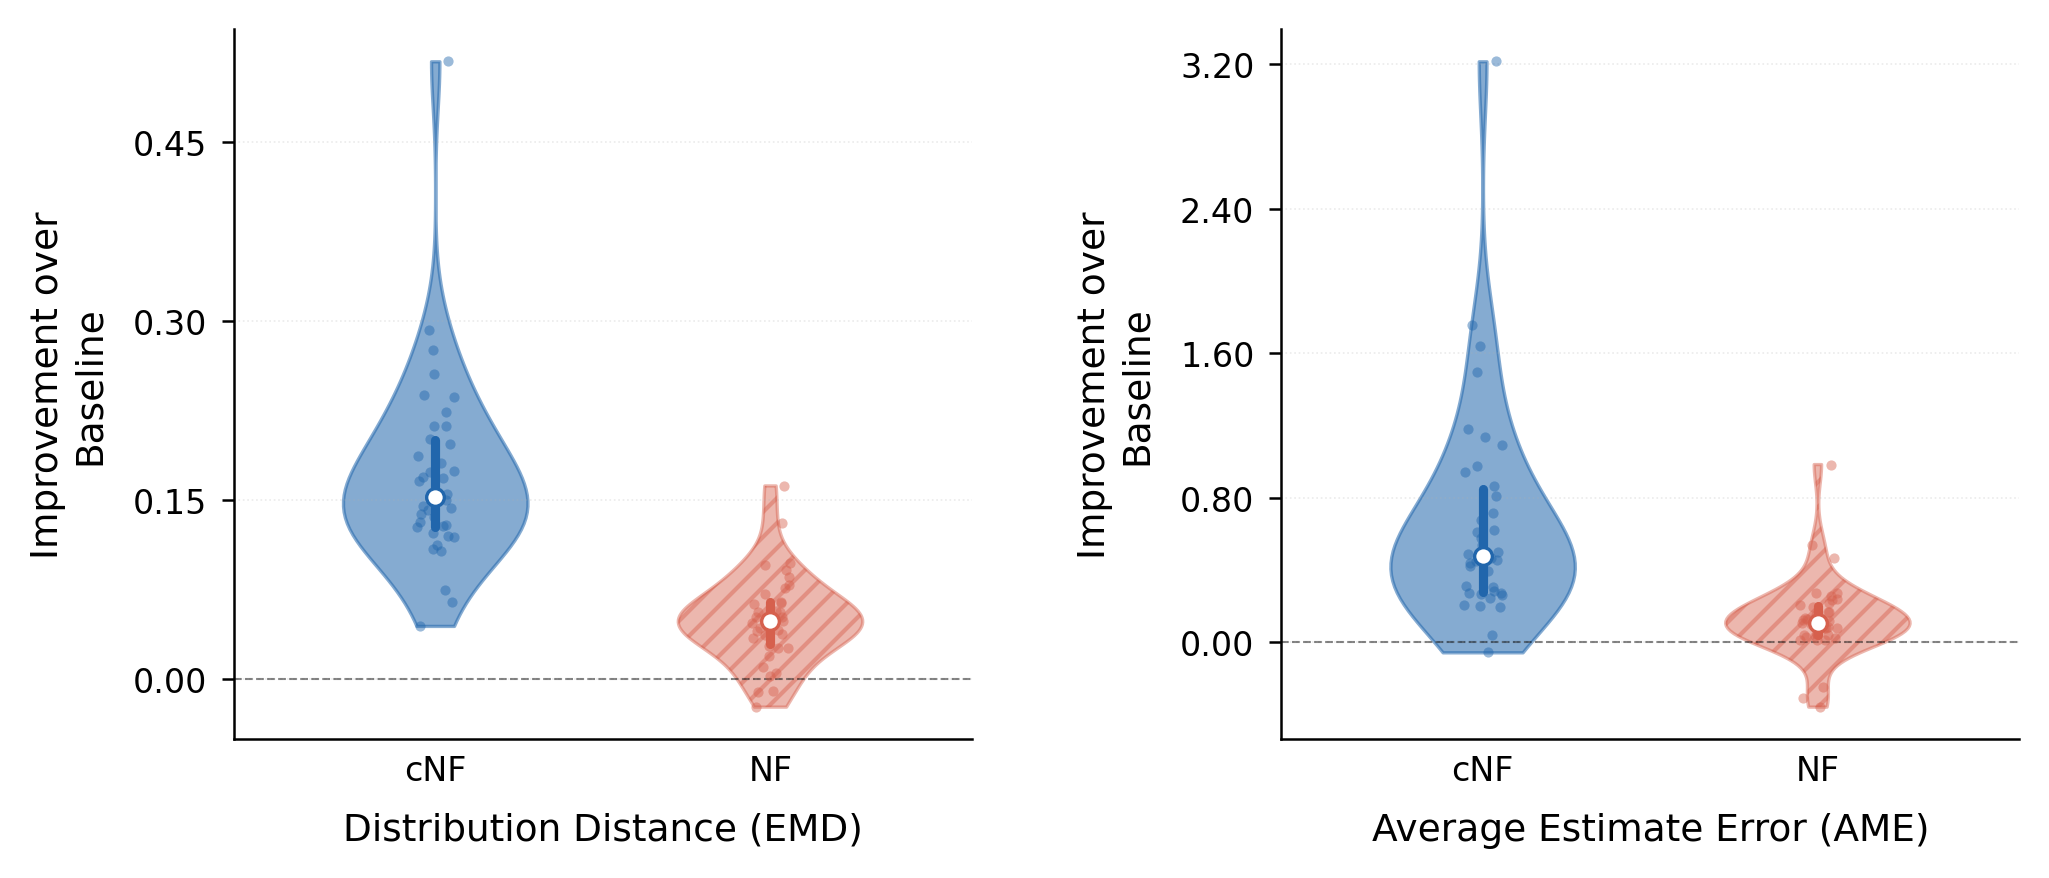

Saved.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── Science Advances style rcParams ─────────────────────────────────────────
plt.rcParams.update({
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
})

C_COMPLETE = "#2166ac"
C_MINIMAL  = "#d6604d"

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    models  = ["complete", "minimal"]
    xs      = [0.0, 1.0]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals, positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # draw IQR box + median manually for cleaner look
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2, solid_capstyle="round", zorder=4)
        ax.scatter(x, med, color="white", s=18, zorder=5, linewidths=0.8,
                   edgecolors=color)

        # individual points as a strip, jittered
        rng = np.random.default_rng(42)
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(x + jitter, vals, color=color, s=6, alpha=0.45,
                   linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"], fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9, labelpad=6)
    ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=6)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)


# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(3.5 * 2, 3.2),   # ~7 × 3.2 in — typical 2-col Science Advances width
)
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.42)

make_violin_panel(axes[0], "emd_improv", "Distribution Distance (EMD)")
make_violin_panel(axes[1], "ame_improv", "Average Estimate Error (AME)")



fig.savefig("violin_improvement.pdf", bbox_inches="tight", dpi=300)
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved.")

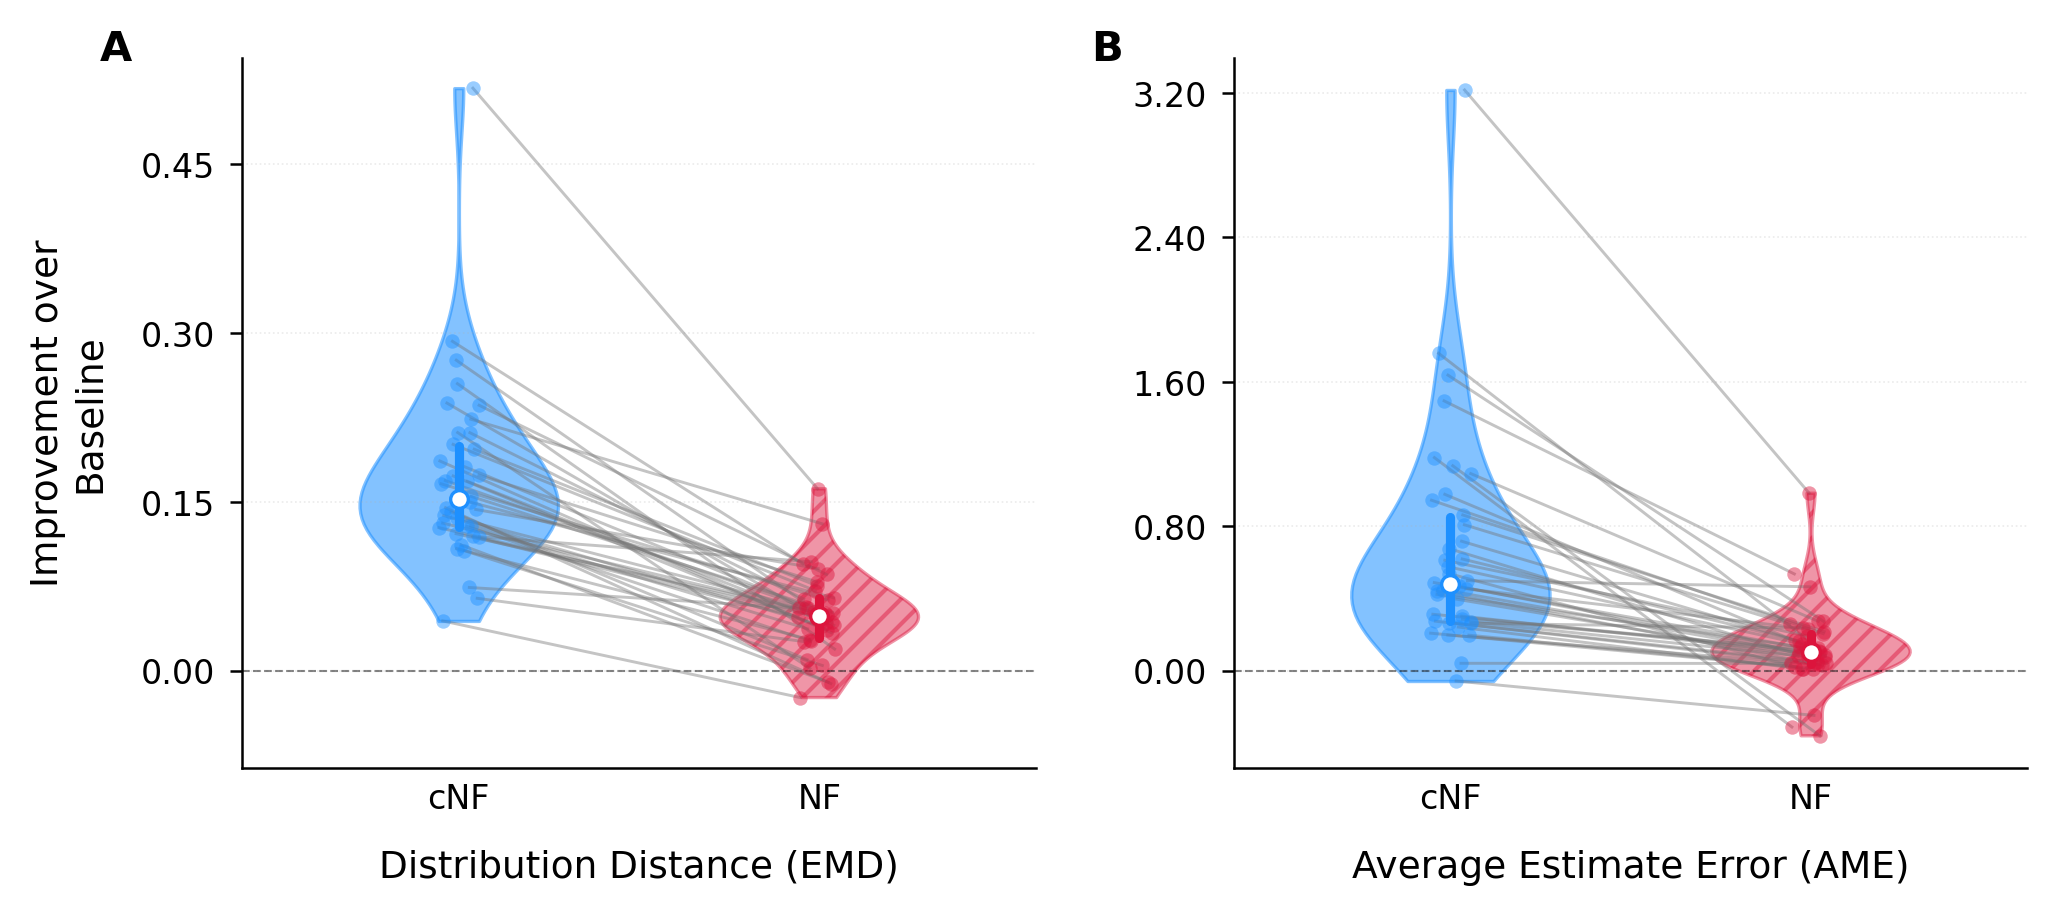

Saved as violin_improvement.svg and violin_improvement.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Helvetica / Science-style rcParams ─────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",   # keep text editable in SVG
})

C_COMPLETE = 'DodgerBlue'
C_MINIMAL  = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label, show_ylabel=False):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    x_complete = 0.0
    x_minimal = 1.0

    models  = ["complete", "minimal"]
    xs      = [x_complete, x_minimal]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    rng = np.random.default_rng(42)

    # violins
    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals,
            positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )

        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # IQR + median
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    # paired lines + points
    vals_complete = merged[f"{metric_col}_complete"].values
    vals_minimal  = merged[f"{metric_col}_minimal"].values

    jitter_complete = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal  = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete + jitter_complete
    x2 = x_minimal + jitter_minimal

    for i in range(len(merged)):
        ax.plot(
            [x1[i], x2[i]],
            [vals_complete[i], vals_minimal[i]],
            color="0.45",
            linewidth=0.7,
            alpha=0.42,
            zorder=2
        )

    ax.scatter(x1, vals_complete, color=C_COMPLETE, s=12, alpha=0.45,
               linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal, color=C_MINIMAL, s=12, alpha=0.45,
               linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)

    if show_ylabel:
        ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=8)
    else:
        ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)

    # panel letter
    ax.text(
        -0.18, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.25)

make_violin_panel(
    axes[0],
    metric_col="emd_improv",
    xlabel="Distribution Distance (EMD)",
    panel_label="A",
    show_ylabel=True
)

make_violin_panel(
    axes[1],
    metric_col="ame_improv",
    xlabel="Average Estimate Error (AME)",
    panel_label="B",
    show_ylabel=False
)

# current limits
ymin_left, ymax_left = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()

# choose the zero position from the right panel as the target
# (you could also use the left one, or an average)
target_frac = (0 - ymin_right) / (ymax_right - ymin_right)

# keep left upper limit fixed, solve for a new left lower limit
new_ymin_left = -target_frac * ymax_left / (1 - target_frac)

# keep right lower limit fixed, solve for a new right upper limit
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)

# set new limits
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

fig.savefig("violin_improvement.svg", bbox_inches="tight")
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()

print("Saved as violin_improvement.svg and violin_improvement.png")

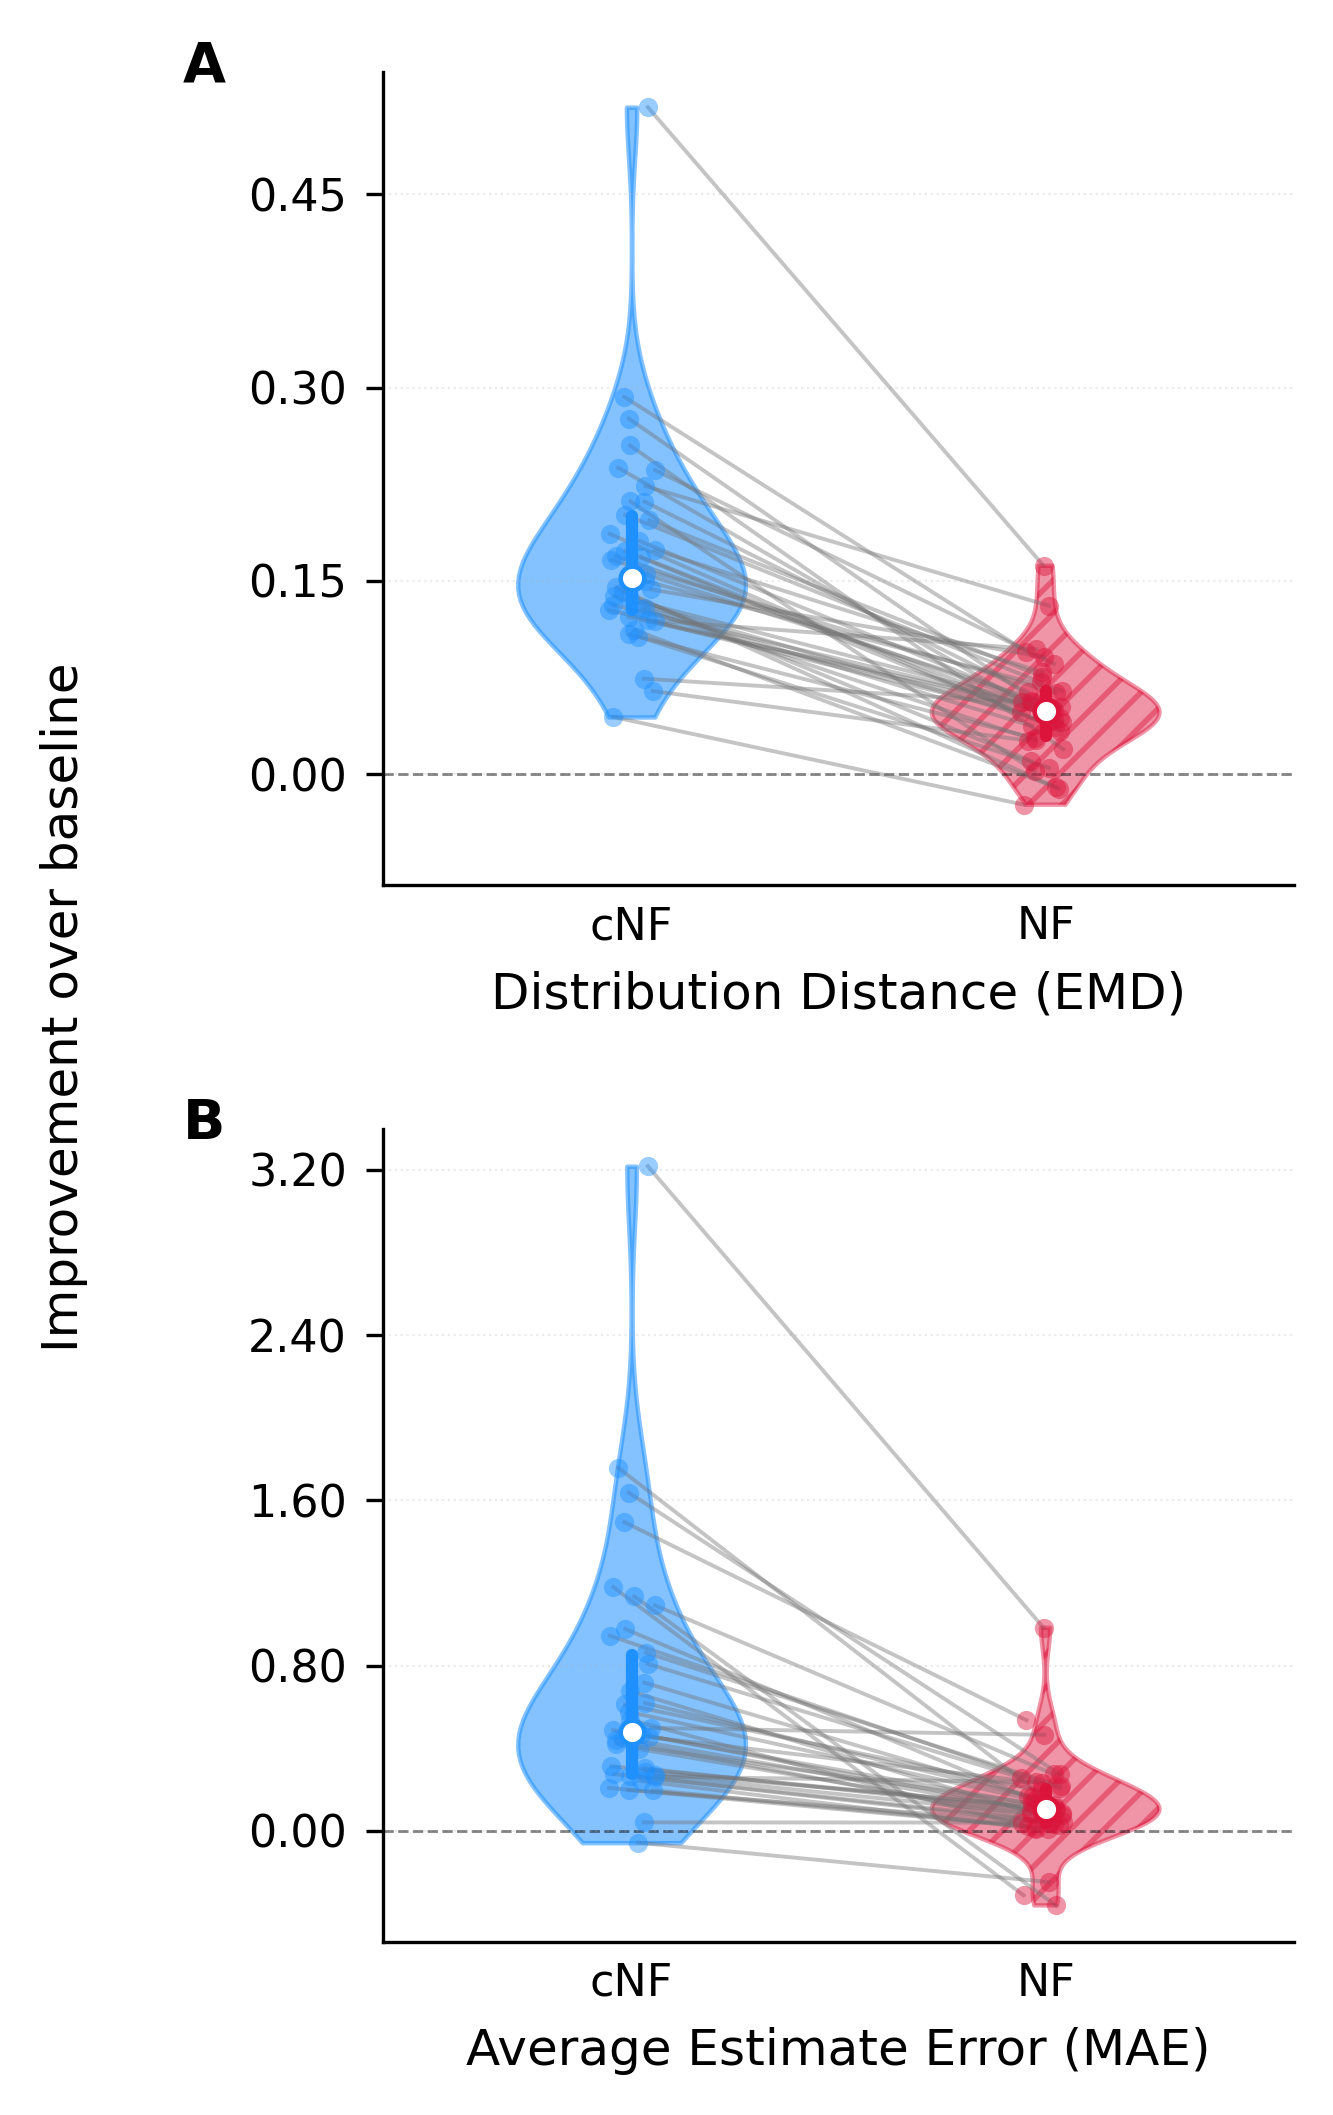

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_COMPLETE = 'DodgerBlue'
C_MINIMAL  = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).dropna()

    x_complete = 0.0
    x_minimal  = 1.0
    models  = ["complete", "minimal"]
    xs      = [x_complete, x_minimal]
    colors  = [C_COMPLETE, C_MINIMAL]
    alphas  = [0.55, 0.45]
    hatches = [None, "////"]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values
        parts = ax.violinplot(
            vals, positions=[x], widths=0.55,
            showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    vals_complete = merged[f"{metric_col}_complete"].values
    vals_minimal  = merged[f"{metric_col}_minimal"].values
    jitter_complete = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal  = rng.uniform(-0.06, 0.06, size=len(merged))
    x1 = x_complete + jitter_complete
    x2 = x_minimal  + jitter_minimal

    for i in range(len(merged)):
        ax.plot([x1[i], x2[i]], [vals_complete[i], vals_minimal[i]],
                color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

    ax.scatter(x1, vals_complete, color=C_COMPLETE, s=12, alpha=0.45,
               linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal,  color=C_MINIMAL,  s=12, alpha=0.45,
               linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=4)
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 1.6)
    ax.tick_params(axis="x", length=0)

    ax.text(
        -0.22, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        va="top", ha="left"
    )

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(3.3, 5.5))
fig.subplots_adjust(left=0.28, right=0.97, top=0.95, bottom=0.10, hspace=0.30)

make_violin_panel(axes[0], metric_col="emd_improv",
                  xlabel="Distribution Distance (EMD)", panel_label="A")
make_violin_panel(axes[1], metric_col="ame_improv",
                  xlabel="Average Estimate Error (MAE)", panel_label="B")

# ── Shared y label centered between both panels ───────────────────────────
y_center = (0.10 + 0.95) / 2
fig.text(
    0.02, y_center,
    "Improvement over baseline",
    fontsize=9, fontweight="normal",
    ha="left", va="center", rotation=90,
)

# ── Align zero across both panels ────────────────────────────────────────
ymin_left,  ymax_left  = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()
target_frac    = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

# ── Save ─────────────────────────────────────────────────────────────────
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_improvement.pdf", bbox_inches="tight")
fig.savefig("violin_improvement.svg", bbox_inches="tight")
plt.show()